----------------------------------------IMPORTS-------------------------------------

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

----------------------------------CHARGER UN FICHIER-----------------------------------

In [6]:
df = pd.read_parquet(
    r"D:\Projet 4\TaxiOut AI\data\year=2008\day_of_week=Friday\part-00054-457d7a39-f2d7-477b-889a-1a5e13ece90d.c000.snappy.parquet"
)

-----------------------------DIMENSIONS----------------------------

In [7]:
df.shape

(350566, 29)

-----------------------PREMIERS LIGNES------------------------------------

In [8]:
df.head()

,month,day_of_month,actual_departure_time,scheduled_departure_time,actual_arrival_time,scheduled_arrival_time,unique_carrier,flight_number,plane_tail_number,actual_elapsed_time,...,cancelled,cancellation_code,diverted,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,date,index
0,1,4,1203.0,1125,1327.0,1240,WN,746,NaN,64.0,...,0,None,0,0.0,0.0,9.0,0.0,78.0,2008-01-04,0
1,1,4,546.0,545,867.0,880,WN,2126,NaN,201.0,...,0,None,0,NaN,NaN,NaN,NaN,NaN,2008-01-04,1
2,1,4,884.0,875,1032.0,1030,WN,45,NaN,88.0,...,0,None,0,NaN,NaN,NaN,NaN,NaN,2008-01-04,2
3,1,4,416.0,415,570.0,570,WN,87,NaN,94.0,...,0,None,0,NaN,NaN,NaN,NaN,NaN,2008-01-04,3
4,1,4,1323.0,1215,0.0,1360,WN,230,NaN,87.0,...,0,None,0,1.0,0.0,2.0,0.0,107.0,2008-01-04,4


--------------------LISTER LES COLONNES-----------------------------------

In [9]:
df.columns.tolist()

['month',
 'day_of_month',
 'actual_departure_time',
 'scheduled_departure_time',
 'actual_arrival_time',
 'scheduled_arrival_time',
 'unique_carrier',
 'flight_number',
 'plane_tail_number',
 'actual_elapsed_time',
 'scheduled_elapsed_time',
 'air_time',
 'arrival_delay',
 'departure_delay',
 'origin',
 'dest',
 'distance',
 'taxi_in',
 'taxi_out',
 'cancelled',
 'cancellation_code',
 'diverted',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay',
 'date',
 'index']

---------------------IDENTIFIER LES TYPES---------------------------------------

In [10]:
df.dtypes

month                         int32
day_of_month                  int32
actual_departure_time       float64
scheduled_departure_time      int32
actual_arrival_time         float64
scheduled_arrival_time        int32
unique_carrier               object
flight_number                 int32
plane_tail_number           float64
actual_elapsed_time         float64
scheduled_elapsed_time      float64
air_time                    float64
arrival_delay               float64
departure_delay             float64
origin                       object
dest                         object
distance                     object
taxi_in                     float64
taxi_out                    float64
cancelled                     int32
cancellation_code            object
diverted                      int32
carrier_delay               float64
weather_delay               float64
nas_delay                   float64
security_delay              float64
late_aircraft_delay         float64
date                        

---------------------------INFORMATIONS GENERALES--------------------------------------

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350566 entries, 0 to 350565
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   month                     350566 non-null  int32  
 1   day_of_month              350566 non-null  int32  
 2   actual_departure_time     339013 non-null  float64
 3   scheduled_departure_time  350566 non-null  int32  
 4   actual_arrival_time       338154 non-null  float64
 5   scheduled_arrival_time    350566 non-null  int32  
 6   unique_carrier            350566 non-null  object 
 7   flight_number             350566 non-null  int32  
 8   plane_tail_number         0 non-null       float64
 9   actual_elapsed_time       338154 non-null  float64
 10  scheduled_elapsed_time    350505 non-null  float64
 11  air_time                  338154 non-null  float64
 12  arrival_delay             338154 non-null  float64
 13  departure_delay           339013 non-null  f

----------ANALYSER LES VALEURS MANQUANTES--------------------------

In [12]:
missing = df.isnull().sum()

missing.sort_values(ascending=False)

plane_tail_number           350566
cancellation_code           339013
late_aircraft_delay         247241
nas_delay                   247241
weather_delay               247241
carrier_delay               247241
security_delay              247241
actual_elapsed_time          12412
taxi_in                      12412
arrival_delay                12412
air_time                     12412
actual_arrival_time          12412
actual_departure_time        11553
taxi_out                     11553
departure_delay              11553
scheduled_elapsed_time          61
scheduled_arrival_time           0
day_of_month                     0
month                            0
flight_number                    0
scheduled_departure_time         0
unique_carrier                   0
origin                           0
dest                             0
distance                         0
cancelled                        0
diverted                         0
date                             0
index               

--------------------------TARGET------------------------------------

In [14]:
df["taxi_out"].describe()

count    339013.000000
mean         17.438517
std          12.174856
min           0.000000
25%          10.000000
50%          14.000000
75%          20.000000
max         262.000000
Name: taxi_out, dtype: float64

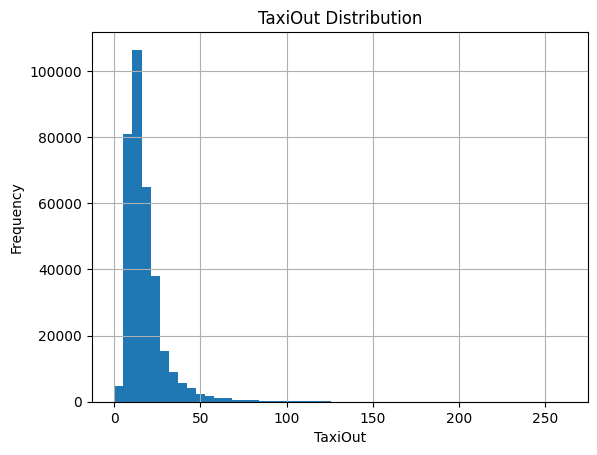

In [15]:

df["taxi_out"].hist(bins=50)

plt.title("TaxiOut Distribution")
plt.xlabel("TaxiOut")
plt.ylabel("Frequency")

plt.show()

-------------------------------Analyser les valeurs manquantes----------------------------------------------

In [16]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

plane_tail_number         350566
cancellation_code         339013
late_aircraft_delay       247241
nas_delay                 247241
weather_delay             247241
security_delay            247241
carrier_delay             247241
actual_arrival_time        12412
air_time                   12412
actual_elapsed_time        12412
taxi_in                    12412
arrival_delay              12412
actual_departure_time      11553
departure_delay            11553
taxi_out                   11553
scheduled_elapsed_time        61
dtype: int64
